# Predicting the Results of Professional Tennis Matches with Machine Learning 

## 1. Setup

### Required libraries

In [ ]:
%pip install -q pandas matplotlib numpy scikit-learn

### Library imports

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

### Configuration

In [74]:
# Dataset file
DATA_DIR = Path.cwd().parent / "data"
DATA_FILE = DATA_DIR / "atp_matches.csv"

# Random state for reproducibility
RANDOM_STATE = 42

# Target feature
TARGET_FEATURE = "winner"

# Present on the dataframe but ignored by classifiers
METADATA_FEATURES = {
    "tournament_id",
    "tournament_start_date",
    "tournament_name",
    "match_num",
    "player1_id",
    "player2_id",
    "player1_name",
    "player2_name",
    "score",
}

# Force certain numeric features to be treated as categorical
AS_CATEGORICAL = {
    "best_of"
}

# Testing and trainingparameters
TRAIN_RATIO = 0.8
TEST_RATIO = 1 - TRAIN_RATIO
NUM_CV_SPLITS = 5

## Helpers

In [25]:
TOURNAMENT_LEVEL_LABELS = {
    "A": "ATP",
    "D": "Davis Cup",
    "F": "ATP Finals",
    "G": "Grand Slam",
    "M": "Masters 1000",
    "N": "Next Gen Finals",
    "O": "Olympics",
}

## 2. Data Loading

In [7]:
if DATA_FILE.is_file():
    raw_df = pd.read_csv(DATA_FILE)
else:
    raise FileNotFoundError(
        "Failed to find or read dataset file."
    )

(num_rows, num_cols) = raw_df.shape
print(f"Dataset has {num_rows} rows and {num_cols} columns.")

Dataset has 189373 rows and 63 columns.


## 3. Data Exploration

### Distribution of matches where the winner is player1

In [59]:
# winner == 1 means player1 won; winner == 2 means player2 won
player1_wins = (raw_df[TARGET_FEATURE] == 1).sum()
n_matches = len(raw_df)
pct_player1 = 100 * player1_wins / n_matches

print(
    f"Player1 win rate: {pct_player1:.2f}% "
    f"({player1_wins:,} of {n_matches:,} matches)"
)

Player1 win rate: 50.13% (94,942 of 189,373 matches)


### Matches per year by tournament level

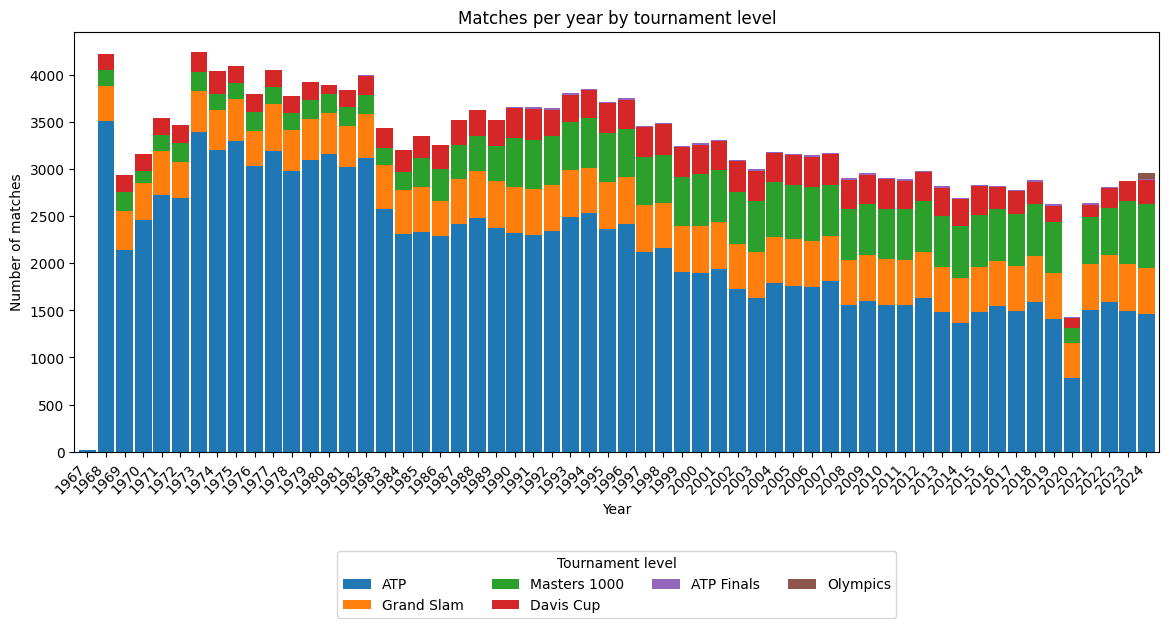

In [26]:
counts_by_year_level = (
    raw_df.groupby(["year", "tournament_level"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Stack order: most common levels at the bottom of the stack
level_order = counts_by_year_level.sum().sort_values(ascending=False).index
counts_by_year_level = counts_by_year_level.reindex(columns=level_order, fill_value=0)
counts_by_year_level = counts_by_year_level.rename(
    columns=lambda c: TOURNAMENT_LEVEL_LABELS.get(str(c), str(c))
)

fig, ax = plt.subplots(figsize=(14, 7))
counts_by_year_level.plot(ax=ax, kind="bar", stacked=True, width=0.9)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_title("Matches per year by tournament level")
n_levels = counts_by_year_level.shape[1]
ax.legend(
    title="Tournament level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(n_levels, 4),
)
plt.xticks(rotation=45, ha="right")
fig.subplots_adjust(bottom=0.28)
plt.show()

### Rank coverage by month

Share of matches where both players have a known ATP ranking (`player1_rank` and `player2_rank` is not empty).

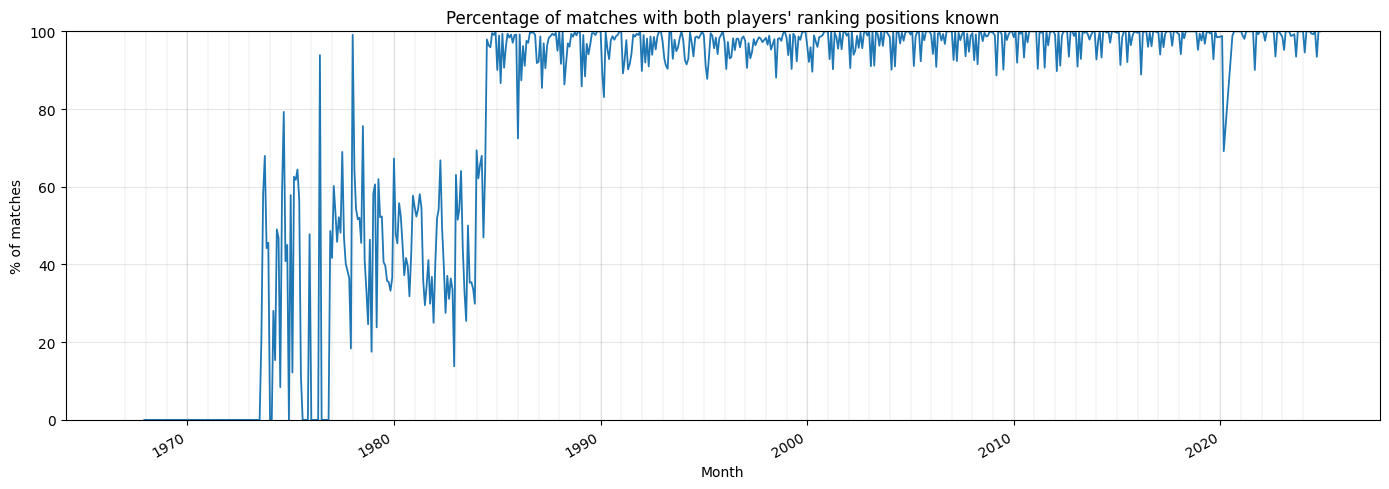

In [23]:
month_dt = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce")
rank_df = raw_df.assign(month=month_dt.dt.to_period("M")).dropna(subset=["month"])
both_ranks_known = rank_df["player1_rank"].notna() & rank_df["player2_rank"].notna()
pct_both_ranks_by_month = (
    rank_df.assign(both_ranks_known=both_ranks_known)
    .groupby("month", observed=True)["both_ranks_known"]
    .mean()
    * 100
)

fig, ax = plt.subplots(figsize=(14, 5))

year_min = pct_both_ranks_by_month.index.min().year
year_max = pct_both_ranks_by_month.index.max().year
for y in range(year_min, year_max + 1):
    ax.axvline(
        pd.Timestamp(year=y, month=1, day=1),
        color="#d8d8d8",
        linewidth=0.3,
        zorder=0,
    )

ax.plot(
    pct_both_ranks_by_month.index.to_timestamp(),
    pct_both_ranks_by_month.values,
    linewidth=1.3,
    zorder=2,
)
ax.set_xlabel("Month")
ax.set_ylabel("% of matches")
ax.set_title("Percentage of matches with both players' ranking positions known")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Favorite wins by month

Among matches where **both** `player1_rank` and `player2_rank` are known, the share of matches won by the **better-ranked** player (lower ATP rank number). Rows with **identical** ranks are excluded. Monthly percentage is over that filtered set only.

Overall: better-ranked player wins 66.24% of eligible matches (92,677 of 139,906).


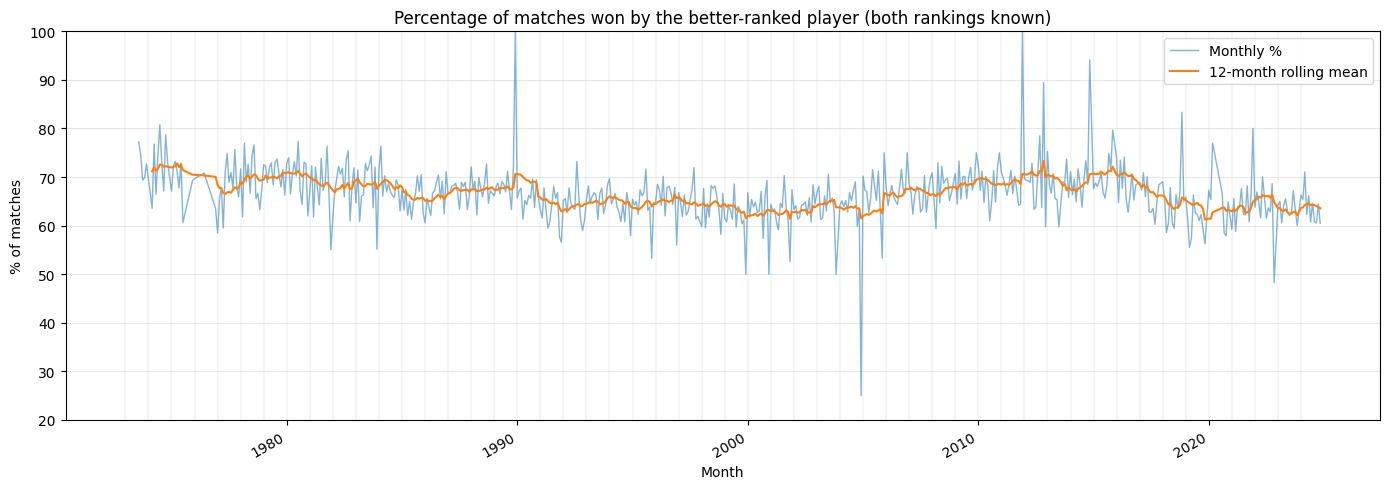

In [ ]:
month_dt = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce")
fav_df = raw_df.assign(month=month_dt.dt.to_period("M")).dropna(subset=["month"])

both_ranks_known = fav_df["player1_rank"].notna() & fav_df["player2_rank"].notna()
fav_df = fav_df.loc[both_ranks_known]

# Drop ties — no unique "better-ranked" player (same rank on both sides)
fav_df = fav_df[fav_df["player1_rank"] != fav_df["player2_rank"]]

favorite_wins = (
    ((fav_df["player1_rank"] < fav_df["player2_rank"]) & (fav_df[TARGET_FEATURE] == 1))
    | ((fav_df["player2_rank"] < fav_df["player1_rank"]) & (fav_df[TARGET_FEATURE] == 2))
)

n_eligible = len(fav_df)
pct_favorite_overall = 100 * favorite_wins.mean()
print(
    f"Overall: better-ranked player wins {pct_favorite_overall:.2f}% of eligible matches "
    f"({int(favorite_wins.sum()):,} of {n_eligible:,})."
)

pct_favorite_by_month = (
    fav_df.assign(favorite_wins=favorite_wins)
    .groupby("month", observed=True)["favorite_wins"]
    .mean()
    * 100
)

ROLL_MONTHS = 12
running_avg = pct_favorite_by_month.rolling(window=ROLL_MONTHS, min_periods=6).mean()

ts = pct_favorite_by_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

year_min = pct_favorite_by_month.index.min().year
year_max = pct_favorite_by_month.index.max().year
for y in range(year_min, year_max + 1):
    ax.axvline(
        pd.Timestamp(year=y, month=1, day=1),
        color="#d8d8d8",
        linewidth=0.3,
        zorder=0,
    )

ax.plot(
    ts,
    pct_favorite_by_month.values,
    linewidth=1.0,
    alpha=0.55,
    label="Monthly %",
    zorder=2,
)
ax.plot(
    ts,
    running_avg.values,
    linewidth=1.5,
    label=f"{ROLL_MONTHS}-month rolling mean",
    zorder=3,
)
ax.set_xlabel("Month")
ax.set_ylabel("% of matches")
ax.set_title(
    "Percentage of matches won by the better-ranked player "
    "(both rankings known)"
)
ax.set_ylim(20, 100)
ax.set_yticks(np.arange(20, 101, 10))
ax.grid(True, alpha=0.3, axis="y", which="major")
ax.legend(loc="best")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Unknown rankings by tournament level after 1985

Among matches where **at least one** of `player1_rank` or `player2_rank` is missing, how those rows split across tournament levels (pie chart). Only matches from **1985** onward are included.

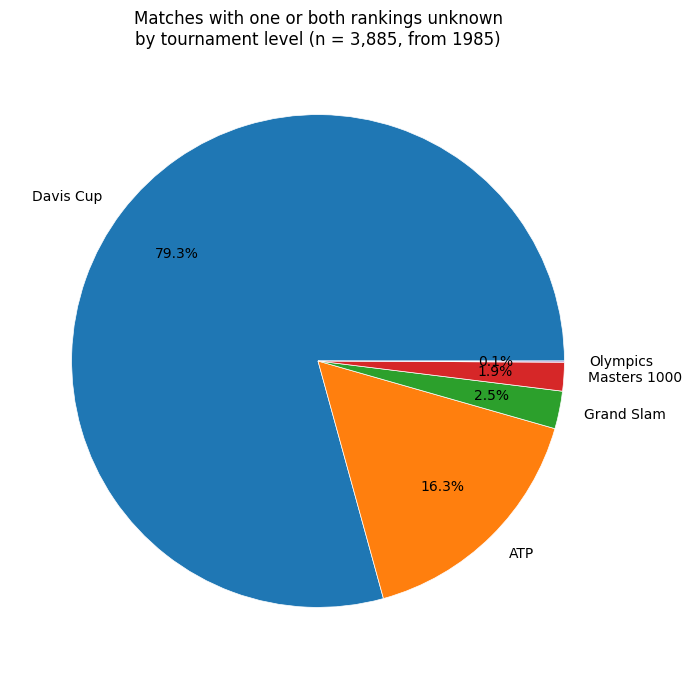

In [28]:
matches_from_1985 = raw_df[raw_df["year"] >= 1985]
one_or_both_unknown = (
    matches_from_1985["player1_rank"].isna()
    | matches_from_1985["player2_rank"].isna()
)
unknown_rank_df = matches_from_1985.loc[one_or_both_unknown]

counts_by_level = unknown_rank_df["tournament_level"].value_counts().sort_values(
    ascending=False
)
labels = [TOURNAMENT_LEVEL_LABELS.get(str(level), str(level)) for level in counts_by_level.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    counts_by_level.values,
    labels=labels,
    autopct="%1.1f%%",
    pctdistance=0.72,
    wedgeprops=dict(linewidth=0.5, edgecolor="white"),
)
ax.set_title(
    "Matches with one or both rankings unknown\nby tournament level "
    f"(n = {len(unknown_rank_df):,}, from 1985)"
)
plt.show()

## 4. Common Training and Testing Infrastructure

### Feature selection

Metadata features are not used as input (leakage) but remain on the feature matrix.

In [71]:
feature_cols = [c for c in raw_df.columns if c != TARGET_FEATURE]
X = raw_df[feature_cols].copy()
y = (raw_df[TARGET_FEATURE] == 1).astype(int)

metadata_cols = [c for c in METADATA_FEATURES if c in X.columns]

numeric_features = [
    c
    for c in X.select_dtypes(include=[np.number]).columns
    if c not in METADATA_FEATURES and c not in AS_CATEGORICAL
]
categorical_features = list(AS_CATEGORICAL) + [
    c
    for c in X.select_dtypes(exclude=[np.number]).columns
    if c not in METADATA_FEATURES
]

print(f"Target feature: {TARGET_FEATURE}")
print(f"Metadata features ({len(metadata_cols)}): {metadata_cols}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Target feature: winner
Metadata features (9): ['player2_name', 'player1_id', 'player2_id', 'match_num', 'score', 'tournament_id', 'tournament_start_date', 'player1_name', 'tournament_name']
Categorical features (5): ['best_of', 'tournament_level', 'surface', 'player1_hand', 'player2_hand']


### Dataset split for training and testing

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE
)

n = len(X)
print(
    f"Train pool: {len(X_train):,} ({len(X_train) / n:.0%}), "
    f"Hold-out test: {len(X_test):,} ({len(X_test) / n:.0%})"
)

Train pool: 151,498 (80%), Hold-out test: 37,875 (20%)


## Training and testing approach

**`GridSearchCV`** searches best parameters using **`NUM_CV_SPLITS`-fold** shuffled `KFold` (not stratified on outcome), **`scoring='roc_auc'`**, then refits the best pipeline on the full training pool for hold-out test evaluation with a ratio of `TEST_RATIO` rows.


In [77]:
def train_model(model_name, estimator, param_grid):
    cv = KFold(n_splits=NUM_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    print(f"\nGrid search for {model_name} model")
    print(f"\nBest accuracy (mean across folds): {grid_search.best_score_:.4f}")
    print(f"Best params: {grid_search.best_params_}")

    return grid_search.best_estimator_

def test_model(model_name, model):
    pred = model.predict(X_test)
    proba_p1 = model.predict_proba(X_test)[:, 1]
    n_correct = int((y_test == pred).sum())
    n_total = len(y_test)
    prec = precision_score(
        y_test, pred, average="binary", pos_label=1, zero_division=0
    )
    rec = recall_score(
        y_test, pred, average="binary", pos_label=1, zero_division=0
    )
    f1 = f1_score(y_test, pred, average="binary", pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, proba_p1)
    print(f"\nTest results for {model_name} model")
    print(
        f"{n_correct:,} / {n_total:,} correct ({n_correct / n_total:.2%}); "
        f"precision={prec:.4f}, recall={rec:.4f}, F1={f1:.4f}, ROC-AUC={auc:.4f}"
    )

def train_and_test_model(model_name, estimator, param_grid):
    model = train_model(model_name, estimator, param_grid)
    test_model(model_name, model)
    return model


## 5. Models

### Random Forest

In [ ]:
RF_MODEL_NAME = "Random Forest"

# RandomForest hyperparameters for GridSearchCV (pipeline step name: "model")
RF_PARAM_GRID = {
    "model__n_estimators": [200],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [2, 4],
    "model__random_state": [RANDOM_STATE],
    "model__class_weight": ["balanced"],
}

_transformers = []
if metadata_cols:
    _transformers.append(("drop_metadata", "drop", metadata_cols))
_transformers.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers.append(
        (
            "cat",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor = ColumnTransformer(transformers=_transformers)

rf_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "model",
            RandomForestClassifier(),
        ),
    ]
)

random_forest = train_and_test_model(RF_MODEL_NAME, rf_pipeline, RF_PARAM_GRID)


Fitting 5 folds for each of 4 candidates, totalling 20 fits



Grid search for Random Forest model

Best accuracy (mean across folds): 0.6963
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}

Test results for Random Forest model
26,282 / 37,875 correct (69.39%); precision=0.6992, recall=0.6900, F1=0.6945, ROC-AUC=0.7669
